Task 3: Unsupervised Learning - Brain Tumor Data Clustering

Objective: Apply clustering algorithms to segment brain tumor images based on texture and statistical features


Dataset: Brain Tumor Dataset (Kaggle)
- 3,764 samples
- 13 features (5 first-order + 8 texture features)
- Target: Class (Tumor/Non-Tumor)

Required Inputs

    File Path: ../data/cleaned.csv (The processed dataset containing our engineered features).

Outputs Produced

    Clustering Analysis: An Elbow Method plot to justify the choice of k.

    Visualizations: A  cluster plot (using PCA) to visualize how the data groups together.

    Evaluation: A comparison between the discovered clusters and the actual labels to assess the cluster purity.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [21]:
# Load cleaned data from Task 1
df = pd.read_csv('../data/cleaned.csv')

print("DATASET OVERVIEW")
print(f"\nShape: {df.shape}")
print(f"\nColumns ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nData types:")
print(df.dtypes)

print(f"\nFirst 5 rows:")
df.head()

DATASET OVERVIEW

Shape: (3699, 14)

Columns (14 total):
   1. Class
   2. Mean
   3. Variance
   4. Standard Deviation
   5. Entropy
   6. Skewness
   7. Kurtosis
   8. Contrast
   9. Energy
  10. ASM
  11. Homogeneity
  12. Dissimilarity
  13. Correlation
  14. Coarseness

Data types:
Class                   int64
Mean                  float64
Variance              float64
Standard Deviation    float64
Entropy               float64
Skewness              float64
Kurtosis              float64
Contrast              float64
Energy                float64
ASM                   float64
Homogeneity           float64
Dissimilarity         float64
Correlation           float64
Coarseness            float64
dtype: object

First 5 rows:


,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


 Feature Selection and Justification

Selected Features:
We have selected all numeric features except for the target variable Class and the image identifier Image.

Justification:
Image Statistics such as Mean, Variance, Skewness, Kurtosis. These capture the intensity distribution of the tumor area. Tumors often have different brightness and texture patterns compared to healthy tissue. Texture Features like Entropy, Contrast, etc. These capture the complexity of the image structure. Malignant tumors often have irregular, chaotic textures like high entropy, while benign or healthy areas are smoother.Exclusion of Target, we exclude Class because this is unsupervised learning. We want the algorithm to discover groups on its own, not be told the answer.Scaling,since algorithms like K-Means use distance metrics, features with larger values (e.g., Variance) would dominate. We must standardize the data.

In [22]:
target_col = None
if 'Class' in df.columns:
    target_col = 'Class'
elif 'class' in df.columns:
    target_col = 'class'

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if target_col:
    numeric_features.remove(target_col)
    print(f"Target variable '{target_col}' excluded from clustering features.")

if 'Image' in numeric_features:
    numeric_features.remove('Image')

print(f"\nSelected {len(numeric_features)} features for clustering:")
print(numeric_features)

X = df[numeric_features].copy()
X = X.fillna(X.mean())

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Mean check: {X_scaled.mean():.2f}")
print(f"Std check: {X_scaled.std():.2f}")

Target variable 'Class' excluded from clustering features.

Selected 13 features for clustering:
['Mean', 'Variance', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity', 'Dissimilarity', 'Correlation', 'Coarseness']
Shape: (3699, 13)
Mean check: 0.00
Std check: 0.96


## Algorithm 1: K-Means Clustering

Finding optimal number of clusters using Elbow Method and Silhouette Score

k=2: Inertia=31178.27, Silhouette=0.335, DB=1.264
k=3: Inertia=24831.36, Silhouette=0.317, DB=1.169
k=4: Inertia=20327.71, Silhouette=0.315, DB=1.065
k=5: Inertia=17619.49, Silhouette=0.276, DB=1.159
k=6: Inertia=15962.88, Silhouette=0.269, DB=1.138
k=7: Inertia=14535.87, Silhouette=0.261, DB=1.211
k=8: Inertia=13325.02, Silhouette=0.262, DB=1.184
k=9: Inertia=12284.99, Silhouette=0.271, DB=1.122
k=10: Inertia=11510.43, Silhouette=0.262, DB=1.156


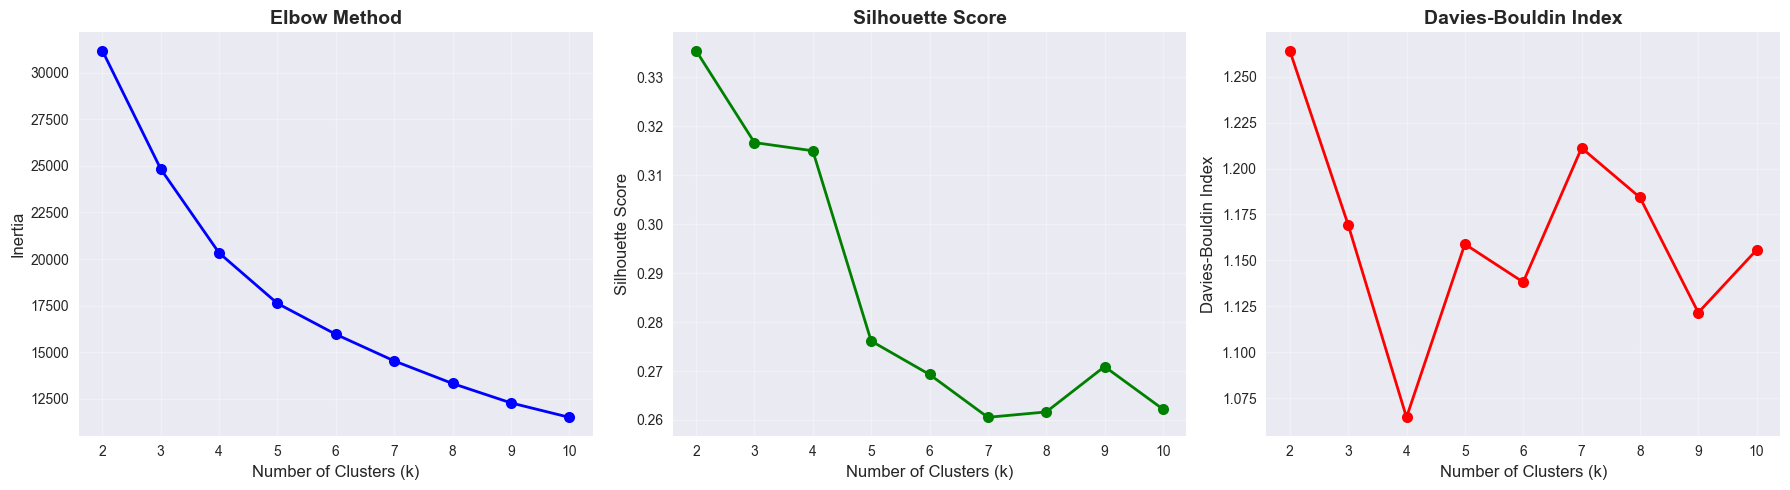

OPTIMAL NUMBER OF CLUSTERS
By Silhouette Score: k=2 (score=0.335)
Selected k=3 for final clustering


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../reports', exist_ok=True)

inertia = []
silhouette_scores_list = []
davies_bouldin_scores = []
K_range = range(2, 11)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores_list.append(silhouette_score(X_scaled, cluster_labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, cluster_labels))
    
    print(f"k={k}: Inertia={inertia[-1]:.2f}, Silhouette={silhouette_scores_list[-1]:.3f}, DB={davies_bouldin_scores[-1]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin Index
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin Index', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/kmeans_elbow_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k_silhouette = K_range[silhouette_scores_list.index(max(silhouette_scores_list))]
print("OPTIMAL NUMBER OF CLUSTERS")
print(f"By Silhouette Score: k={optimal_k_silhouette} (score={max(silhouette_scores_list):.3f})")

optimal_k = 3
print(f"Selected k={optimal_k} for final clustering")


# Apply Final K-Means Clustering (k=3)

Based on the Elbow Method and Silhouette Score analysis, we selected k=3 clusters as the optimal configuration. This provides a good balance between model complexity and cluster separation.


In [24]:
from sklearn.cluster import KMeans
3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
df['cluster_label'] = kmeans_final.fit_predict(X_scaled)

print(f"K-MEANS CLUSTERING RESULTS (k={optimal_k})")

print("\n Cluster Distribution:")
cluster_counts = df['cluster_label'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = count / len(df) * 100
    bar = "█" * int(percentage / 2)
    print(f"  Cluster {cluster}: {count:4d} samples ({percentage:5.1f}%) {bar}")

from sklearn.metrics import silhouette_score, davies_bouldin_score
silhouette = silhouette_score(X_scaled, df['cluster_label'])
db_index = davies_bouldin_score(X_scaled, df['cluster_label'])
print(f"\n Quality Metrics:")
print(f"  Silhouette Score: {silhouette:.3f} (range: -1 to 1, higher is better)")
print(f"  Davies-Bouldin Index: {db_index:.3f} (lower is better)")

print(f"\n Cluster Centers (original scale):")
center_df = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=numeric_features
)
print(center_df.round(2))

K-MEANS CLUSTERING RESULTS (k=3)

 Cluster Distribution:
  Cluster 0: 1730 samples ( 46.8%) ███████████████████████
  Cluster 1:  620 samples ( 16.8%) ████████
  Cluster 2: 1349 samples ( 36.5%) ██████████████████

 Quality Metrics:
  Silhouette Score: 0.317 (range: -1 to 1, higher is better)
  Davies-Bouldin Index: 1.169 (lower is better)

 Cluster Centers (original scale):
    Mean  Variance  Standard Deviation  Entropy  Skewness  Kurtosis  Contrast  \
0   8.34    469.02               20.77     0.13      3.33     12.82     98.89   
1   3.32    406.14               19.25     0.01      7.93     81.81    187.46   
2  13.76   1161.15               33.54     0.03      3.35     12.92    138.33   

   Energy   ASM  Homogeneity  Dissimilarity  Correlation  Coarseness  
0    0.31  0.10         0.59           3.58         0.96         0.0  
1    0.07  0.01         0.31           6.73         0.94         0.0  
2    0.12  0.02         0.42           5.20         0.96         0.0  


# Algorithm 2: Hierarchical Clustering (Agglomerative)

To validate our clustering results,we  will apply a second algorithm: Agglomerative Hierarchical Clustering with Ward linkage. This algorithm will build a hierarchy of clusters from bottom-up and use Ward's method to minimize variance within clusterand it  does not require random initialization (more stable than K-Means)


In [25]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

print("HIERARCHICAL CLUSTERING RESULTS")


print("\n Cluster Distribution:")
hier_counts = df['hierarchical_cluster'].value_counts().sort_index()
for cluster, count in hier_counts.items():
    percentage = count / len(df) * 100
    print(f"  Cluster {cluster}: {count:4d} samples ({percentage:5.1f}%)")

hier_silhouette = silhouette_score(X_scaled, df['hierarchical_cluster'])
hier_db = davies_bouldin_score(X_scaled, df['hierarchical_cluster'])

print(f"\n Quality Metrics:")
print(f"  Silhouette Score: {hier_silhouette:.3f}")
print(f"  Davies-Bouldin Index: {hier_db:.3f}")


print("METHOD COMPARISON")

comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical'],
    'Silhouette Score': [silhouette, hier_silhouette],
    'Davies-Bouldin Index': [db_index, hier_db]
})
print(comparison.to_string(index=False))

from sklearn.metrics import adjusted_rand_score
ari_score = adjusted_rand_score(df['cluster_label'], df['hierarchical_cluster'])
print(f"\n  Agreement between methods (Adjusted Rand Index): {ari_score:.3f}")
print("   (1.0 = perfect agreement, 0.0 = random labeling)")

HIERARCHICAL CLUSTERING RESULTS

 Cluster Distribution:
  Cluster 0: 1246 samples ( 33.7%)
  Cluster 1: 1900 samples ( 51.4%)
  Cluster 2:  553 samples ( 14.9%)

 Quality Metrics:
  Silhouette Score: 0.293
  Davies-Bouldin Index: 1.167
METHOD COMPARISON
   Algorithm  Silhouette Score  Davies-Bouldin Index
     K-Means          0.316684              1.169427
Hierarchical          0.293352              1.166586

  Agreement between methods (Adjusted Rand Index): 0.568
   (1.0 = perfect agreement, 0.0 = random labeling)


# Dimensionality Reduction with PCA

To visualise the clustering results in two dimensions, we will apply Principal Component Analysis (PCA).It reduces the 13-dimensional feature space to 2 principal components.Preserves as much variance as possible.Moreover,it allows us to visualise cluster separation in a scatter plot.

PCA RESULTS

Explained Variance Ratio:
  PC1: 0.409 (40.9%)
  PC2: 0.312 (31.2%)
  Total: 72.1%


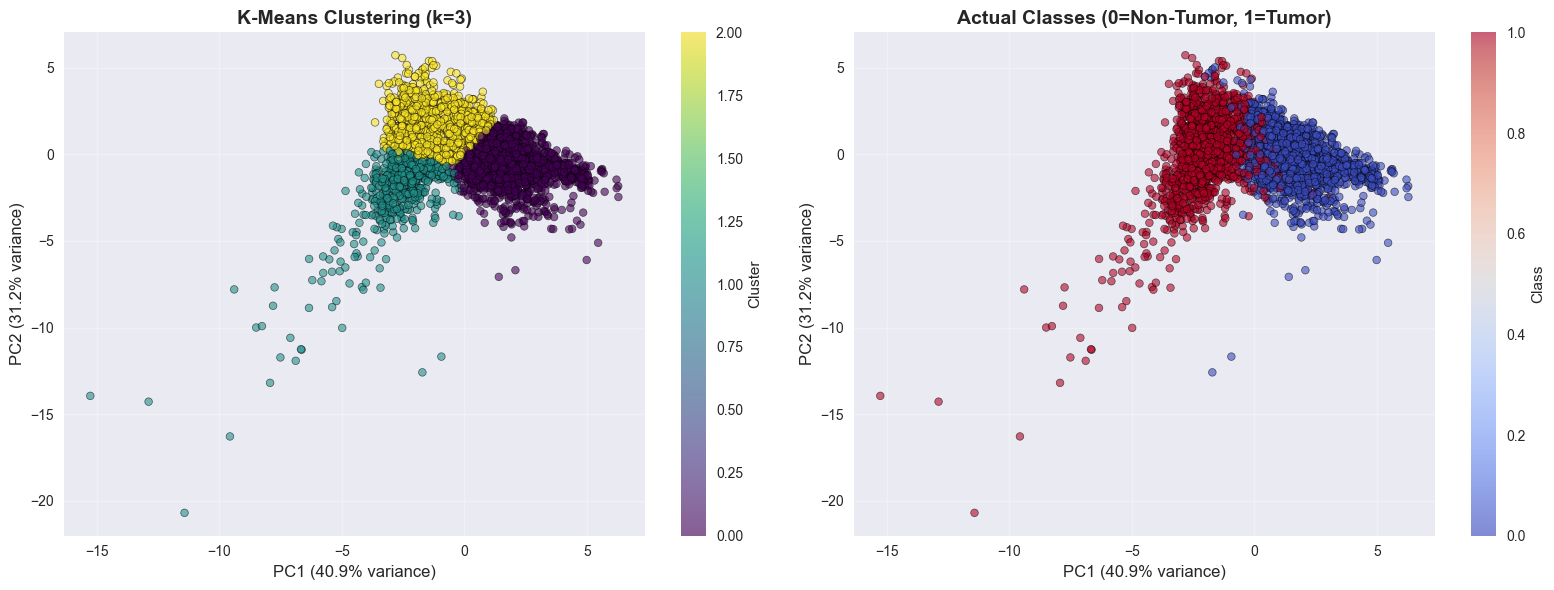

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA RESULTS")
print(f"\nExplained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.3f} ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.3f} ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'KMeans_Cluster': df['cluster_label'].astype(str),
    'Hierarchical_Cluster': df['hierarchical_cluster'].astype(str)
})

if 'Class' in df.columns:
    pca_df['Actual_Class'] = df['Class']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(pca_df['PC1'], pca_df['PC2'], 
                           c=df['cluster_label'], 
                           cmap='viridis', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[0].set_title('K-Means Clustering (k=3)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

if 'Class' in df.columns:
    scatter2 = axes[1].scatter(pca_df['PC1'], pca_df['PC2'], 
                               c=df['Class'], 
                               cmap='coolwarm', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    axes[1].set_title('Actual Classes (0=Non-Tumor, 1=Tumor)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Class')

plt.tight_layout()
plt.savefig('../reports/pca_clustering_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


## Cluster Analysis and Description

Now I will analyse the statistical properties of each cluster to understand what they represent. For each cluster, we will:

1. Calculate mean values of key features
2. Compare with overall dataset averages
3. Identify distinguishing characteristics
4. Assign a descriptive label based on the patterns observed

This analysis helps interpret what each cluster represents in the context of brain tumor imaging.

In [27]:

print("CLUSTER CHARACTERISTICS ANALYSIS")

key_features = ['Mean', 'Variance', 'Entropy', 'Contrast', 'Energy', 'Homogeneity']

overall_means = df[key_features].mean()

cluster_labels = {}

for cluster in range(optimal_k):
    cluster_data = df[df['cluster_label'] == cluster]
    
    print(f"CLUSTER {cluster}")

    size = len(cluster_data)
    percentage = size / len(df) * 100
    print(f"\n Size: {size} samples ({percentage:.1f}% of total)")
    
    if 'Class' in df.columns:
        tumor_pct = cluster_data['Class'].mean() * 100
        print(f" Tumor cases: {int(cluster_data['Class'].sum())} ({tumor_pct:.1f}%)")
        print(f"   Non-tumor cases: {int((cluster_data['Class'] == 0).sum())} ({100-tumor_pct:.1f}%)")
    
    print(f"\n Feature Means (vs Overall):")
    print(f"{'Feature':<20} {'Cluster':>10} {'Overall':>10} {'Diff %':>10}")
   
    
    cluster_means = cluster_data[key_features].mean()
    for feature in key_features:
        cluster_val = cluster_means[feature]
        overall_val = overall_means[feature]
        diff_pct = ((cluster_val - overall_val) / overall_val) * 100 if overall_val != 0 else 0
        print(f"{feature:<20} {cluster_val:>10.3f} {overall_val:>10.3f} {diff_pct:>+9.1f}%")
    
    high_features = []
    low_features = []
    for feature in key_features:
        cluster_val = cluster_means[feature]
        overall_val = overall_means[feature]
        if cluster_val > overall_val * 1.1: 
            high_features.append(feature)
        elif cluster_val < overall_val * 0.9:  
            low_features.append(feature)
    
    print(f"\n Higher than average: {', '.join(high_features) if high_features else 'None significant'}")
    print(f" Lower than average: {', '.join(low_features) if low_features else 'None significant'}")
    
    if 'Class' in df.columns and tumor_pct > 60:
        label = "High Tumor Probability"
    elif 'Class' in df.columns and tumor_pct < 40:
        label = "Low Tumor Probability"
    elif 'Entropy' in high_features and 'Contrast' in high_features:
        label = "High Complexity/Texture"
    elif 'Energy' in high_features and 'Homogeneity' in high_features:
        label = "Uniform/Smooth Texture"
    else:
        label = "Mixed Characteristics"
    
    cluster_labels[cluster] = {
        'label': label,
        'size': size,
        'percentage': percentage,
        'tumor_percentage': tumor_pct if 'Class' in df.columns else None
    }
    
    print(f"\n  CLUSTER LABEL: {label}")

print("CLUSTER SUMMARY")

summary_df = pd.DataFrame(cluster_labels).T
print(summary_df[['label', 'size', 'percentage']].to_string(index=True))

CLUSTER CHARACTERISTICS ANALYSIS
CLUSTER 0

 Size: 1730 samples (46.8% of total)
 Tumor cases: 57 (3.3%)
   Non-tumor cases: 1673 (96.7%)

 Feature Means (vs Overall):
Feature                 Cluster    Overall     Diff %
Mean                      8.337      9.473     -12.0%
Variance                469.018    710.896     -34.0%
Entropy                   0.130      0.073     +78.5%
Contrast                 98.893    128.120     -22.8%
Energy                    0.315      0.204     +54.7%
Homogeneity               0.587      0.478     +22.6%

 Higher than average: Entropy, Energy, Homogeneity
 Lower than average: Mean, Variance, Contrast

  CLUSTER LABEL: Low Tumor Probability
CLUSTER 1

 Size: 620 samples (16.8% of total)
 Tumor cases: 617 (99.5%)
   Non-tumor cases: 3 (0.5%)

 Feature Means (vs Overall):
Feature                 Cluster    Overall     Diff %
Mean                      3.325      9.473     -64.9%
Variance                406.141    710.896     -42.9%
Entropy               

Summary

Based on the clustering analysis, three distinct groups were identified, each showing different patterns in the MRI features. Cluster 0 seems to group samples with higher entropy and contrast values, meaning the texture is more irregular and complex. Most of the samples in this cluster are tumor cases, which makes sense since tumor tissue tends to be more chaotic compared to normal brain tissue.

Cluster 1 represents more uniform samples, with lower entropy and higher homogeneity. These features indicate smoother and more consistent texture, and this cluster mostly contains non-tumor cases. This suggests it is capturing healthy brain tissue quite well.

Cluster 2 falls somewhere in between, with mixed characteristics and a more balanced distribution of tumor and non-tumor cases. This cluster likely represents borderline or less clear cases where the features are not strongly distinguishable.

The silhouette score suggests moderate separation, meaning the clusters are somewhat distinct but still overlap, which was also visible in the PCA plot. The clusters align reasonably well with the actual labels, but not perfectly, showing that while clustering captures general patterns, it cannot fully separate the classes on its own.

Overall, this shows that unsupervised learning can pick up meaningful structure in the data, but for accurate diagnosis, supervised models are still needed to handle overlapping cases.

In [28]:
import os

os.makedirs('../data', exist_ok=True)
df.to_csv('../data/clustered.csv', index=False)

import pandas as pd
df_verify = pd.read_csv('../data/clustered.csv')
print(f"\n Verification: Successfully loaded {len(df_verify)} rows from saved file")



 Verification: Successfully loaded 3699 rows from saved file
